In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
g = 9.81     # gravity (m/s^2)
L = 1.0      # length (m)
theta_0 = 0.2  # initial angle (rad)

t_min, t_max = 0.0, 10.0

In [3]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32,32),
            nn.Tanh(),
            nn.Linear(32,1)
        )
    def forward(self, t):
        return self.net(t)

In [4]:
def pinn_loss(model, t):
    t.requires_grad = True

    theta = model(t)

    theta_t = torch.autograd.grad(
        theta, t, grad_outputs = torch.ones_like(theta), create_graph = True
    )[0]

    theta_tt = torch.autograd.grad(
        theta_t, t, grad_outputs=torch.ones_like(theta_t), create_graph=True
    )[0]

    physics_residual = theta_tt + (g / L) * theta

    physics_loss = torch.mean(physics_residual**2)

    theta_0_pred = model(torch.tensor([[0.0]]))
    theta_t_0_pred = theta_t[0]

    ic_loss = (theta_0_pred - theta_0)**2 + theta_t_0_pred**2

    return physics_loss + ic_loss

In [5]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100000

loss_history = []

for epoch in range(epochs+1):
    optimizer.zero_grad()

    t_train = torch.linspace(t_min, t_max, 100).reshape(-1, 1)
    loss = pinn_loss(model, t_train)

    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

Epoch 0, Loss = 0.862714
Epoch 500, Loss = 0.030781
Epoch 1000, Loss = 0.025376
Epoch 1500, Loss = 0.020689
Epoch 2000, Loss = 0.019273
Epoch 2500, Loss = 0.018586
Epoch 3000, Loss = 0.018220
Epoch 3500, Loss = 0.017880
Epoch 4000, Loss = 0.017614
Epoch 4500, Loss = 0.017366
Epoch 5000, Loss = 0.017167
Epoch 5500, Loss = 0.016974
Epoch 6000, Loss = 0.017458
Epoch 6500, Loss = 0.016655
Epoch 7000, Loss = 0.016757
Epoch 7500, Loss = 0.016371
Epoch 8000, Loss = 0.023001
Epoch 8500, Loss = 0.016115
Epoch 9000, Loss = 0.016119
Epoch 9500, Loss = 0.015877
Epoch 10000, Loss = 0.015752
Epoch 10500, Loss = 0.015673
Epoch 11000, Loss = 0.015570
Epoch 11500, Loss = 0.015551
Epoch 12000, Loss = 0.015452
Epoch 12500, Loss = 0.015378
Epoch 13000, Loss = 0.015300
Epoch 13500, Loss = 0.015274
Epoch 14000, Loss = 0.015208
Epoch 14500, Loss = 0.015310
Epoch 15000, Loss = 0.015134
Epoch 15500, Loss = 0.015075
Epoch 16000, Loss = 0.015058
Epoch 16500, Loss = 0.015005
Epoch 17000, Loss = 0.015232
Epoch 175

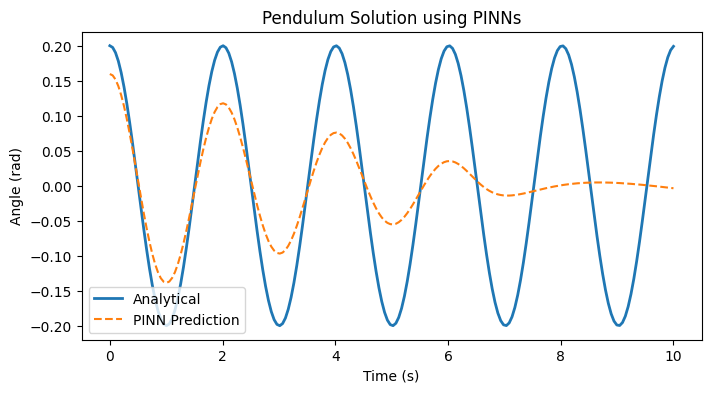

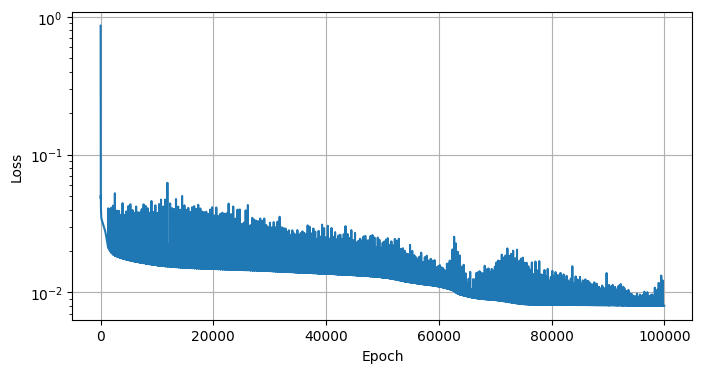

In [6]:
t_test = torch.linspace(t_min, t_max, 200).reshape(-1, 1)
theta_pinn = model(t_test).detach().numpy()

omega = np.sqrt(g / L)
theta_exact = theta_0 * np.cos(omega * t_test.numpy())

plt.figure(figsize=(8, 4))
plt.plot(t_test, theta_exact, label="Analytical", linewidth=2)
plt.plot(t_test, theta_pinn, "--", label="PINN Prediction")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.legend()
plt.title("Pendulum Solution using PINNs")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.grid(True)
plt.show()